In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

print("Everything works! 🎉")

Everything works! 🎉


In [2]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv")

performance = pd.read_csv("../data/processed/clean_scheme_performance.csv")

transactions = pd.read_csv("../data/processed/clean_investor_transactions.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [3]:
print(nav.shape)

print(performance.shape)

print(transactions.shape)

print(aum.shape)

print(sip.shape)

print(category.shape)

print(folio.shape)

print(holdings.shape)

(46000, 3)
(40, 19)
(32778, 13)
(90, 5)
(48, 6)
(144, 3)
(21, 6)
(322, 8)


In [4]:
nav["date"] = pd.to_datetime(nav["date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

# Exploratory Data Analysis (EDA)

This notebook explores the Mutual Fund datasets using statistical summaries and visualizations.

In [5]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [7]:
nav["amfi_code"].nunique()

40

In [8]:
nav = nav.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [9]:
nav.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [11]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="lightgreen",
    opacity=0.20,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="lightcoral",
    opacity=0.20,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.show()

In [12]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

In [13]:
aum.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

In [14]:
aum["date"] = pd.to_datetime(aum["date"])

In [15]:
aum["year"] = aum["date"].dt.year

In [16]:
print(aum["year"].unique())

[2022 2023 2024 2025]


In [17]:
aum = aum[aum["year"].between(2022, 2025)]

C:\Users\Prachi\AppData\Local\Temp\ipykernel_182816\3944927158.py:29: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Prachi\Desktop\bluestock_mf_capestone\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


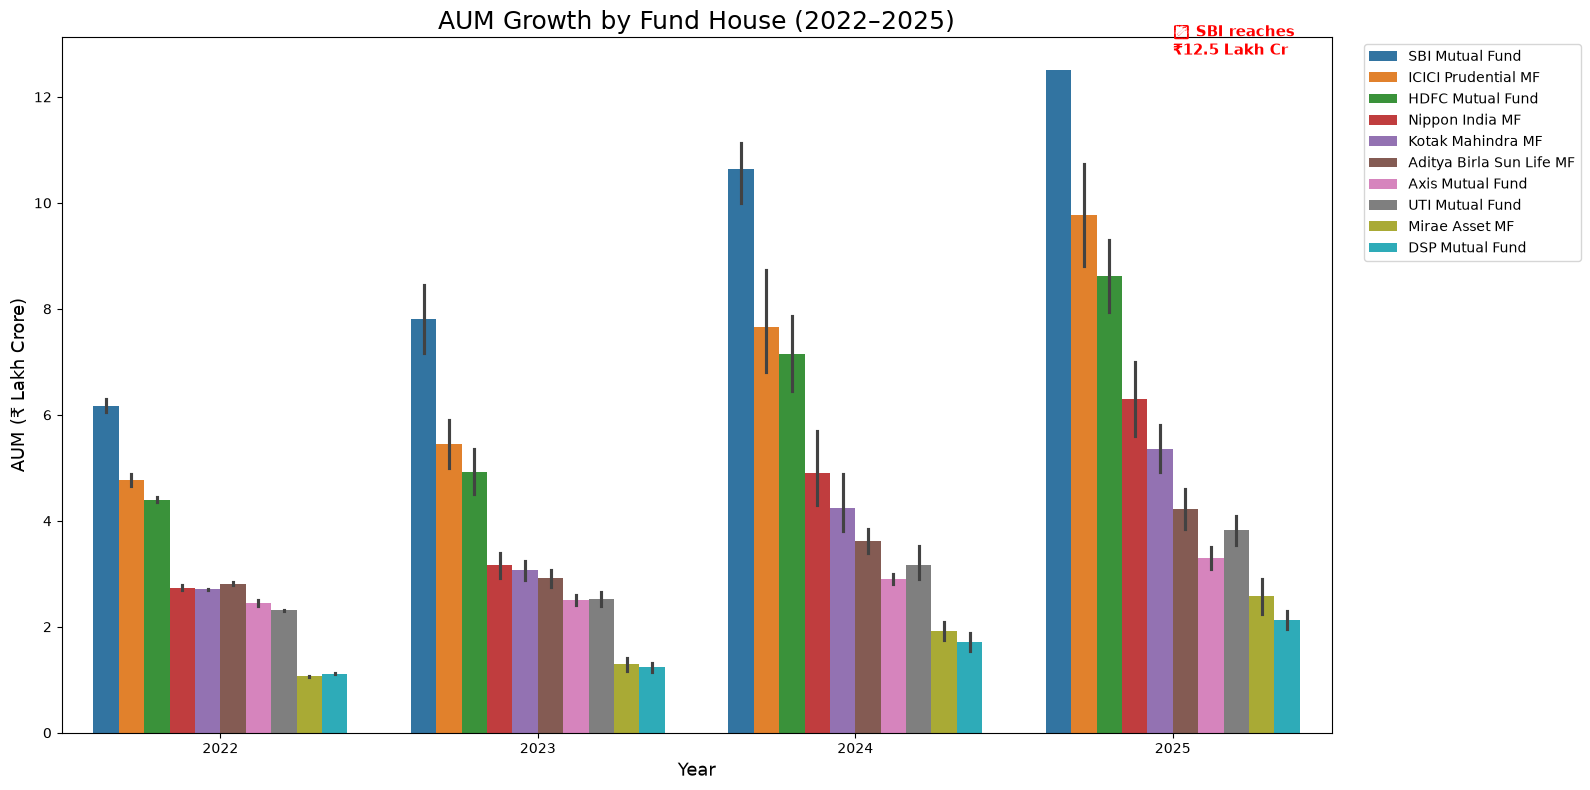

In [20]:
plt.figure(figsize=(16,8))

ax = sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=18)
plt.xlabel("Year", fontsize=13)
plt.ylabel("AUM (₹ Lakh Crore)", fontsize=13)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

# Highlight SBI milestone
plt.text(
    3,          # near year 2025
    12.8,       # slightly above the bar
    "⭐ SBI reaches\n₹12.5 Lakh Cr",
    fontsize=11,
    color="red",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [19]:
sbi = aum[aum["fund_house"].str.contains("SBI", case=False, na=False)]

print(sbi)

         date       fund_house  aum_lakh_crore  aum_crore  num_schemes  year
0  2022-03-31  SBI Mutual Fund            6.05     605000          186  2022
10 2022-09-30  SBI Mutual Fund            6.30     630000          186  2022
20 2023-03-31  SBI Mutual Fund            7.17     717000          186  2023
30 2023-09-30  SBI Mutual Fund            8.45     845000          186  2023
40 2024-03-31  SBI Mutual Fund           10.00    1000000          186  2024
50 2024-09-30  SBI Mutual Fund           10.80    1080000          186  2024
60 2024-12-31  SBI Mutual Fund           11.14    1114000          186  2024
70 2025-03-31  SBI Mutual Fund           12.50    1250000          186  2025
80 2025-12-31  SBI Mutual Fund           12.50    1250000          186  2025


In [21]:
plt.savefig(
    "../reports/charts/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [22]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

In [23]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

In [24]:
sip["month"] = pd.to_datetime(sip["month"])

In [25]:
print(sip["month"].min())
print(sip["month"].max())

2022-01-01 00:00:00
2025-12-01 00:00:00


In [28]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (Jan 2022 – Dec 2025)",
    markers=True
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="⭐ All-Time High<br>₹31,002 Cr",
    showarrow=True,
    arrowhead=2,
    ax=-60,
    ay=-70
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)"
)

fig.show()

In [27]:
sip.loc[sip["sip_inflow_crore"].idxmax()]

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [29]:
fig.write_image("../reports/charts/sip_inflow_trend.png")

In [30]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

In [31]:
category.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [32]:
category["month"] = pd.to_datetime(category["month"])

In [33]:
category["month_year"] = category["month"].dt.strftime("%b-%Y")

In [34]:
heatmap_data = category.pivot(
    index="category",
    columns="month_year",
    values="net_inflow_crore"
)

In [35]:
heatmap_data.head()

month_year,Apr-2024,Aug-2024,Dec-2024,Feb-2025,Jan-2025,Jul-2024,Jun-2024,Mar-2025,May-2024,Nov-2024,Oct-2024,Sep-2024
category,,,,,,,,,,,,
ELSS,466.0,499.0,521.0,437.0,516.0,471.0,472.0,500.0,553.0,571.0,537.0,537.0
Flexi Cap,4947.0,5562.0,4654.0,6068.0,5603.0,4869.0,4478.0,4767.0,5529.0,6111.0,6004.0,5397.0
Gilt,784.0,952.0,831.0,942.0,744.0,959.0,864.0,956.0,836.0,704.0,898.0,925.0
Hybrid,2955.0,3684.0,3538.0,3360.0,2967.0,3291.0,3163.0,2830.0,3487.0,3264.0,3314.0,3015.0
Large & Mid Cap,4214.0,5411.0,4878.0,5524.0,4816.0,5023.0,4610.0,4243.0,4368.0,5556.0,4581.0,4528.0


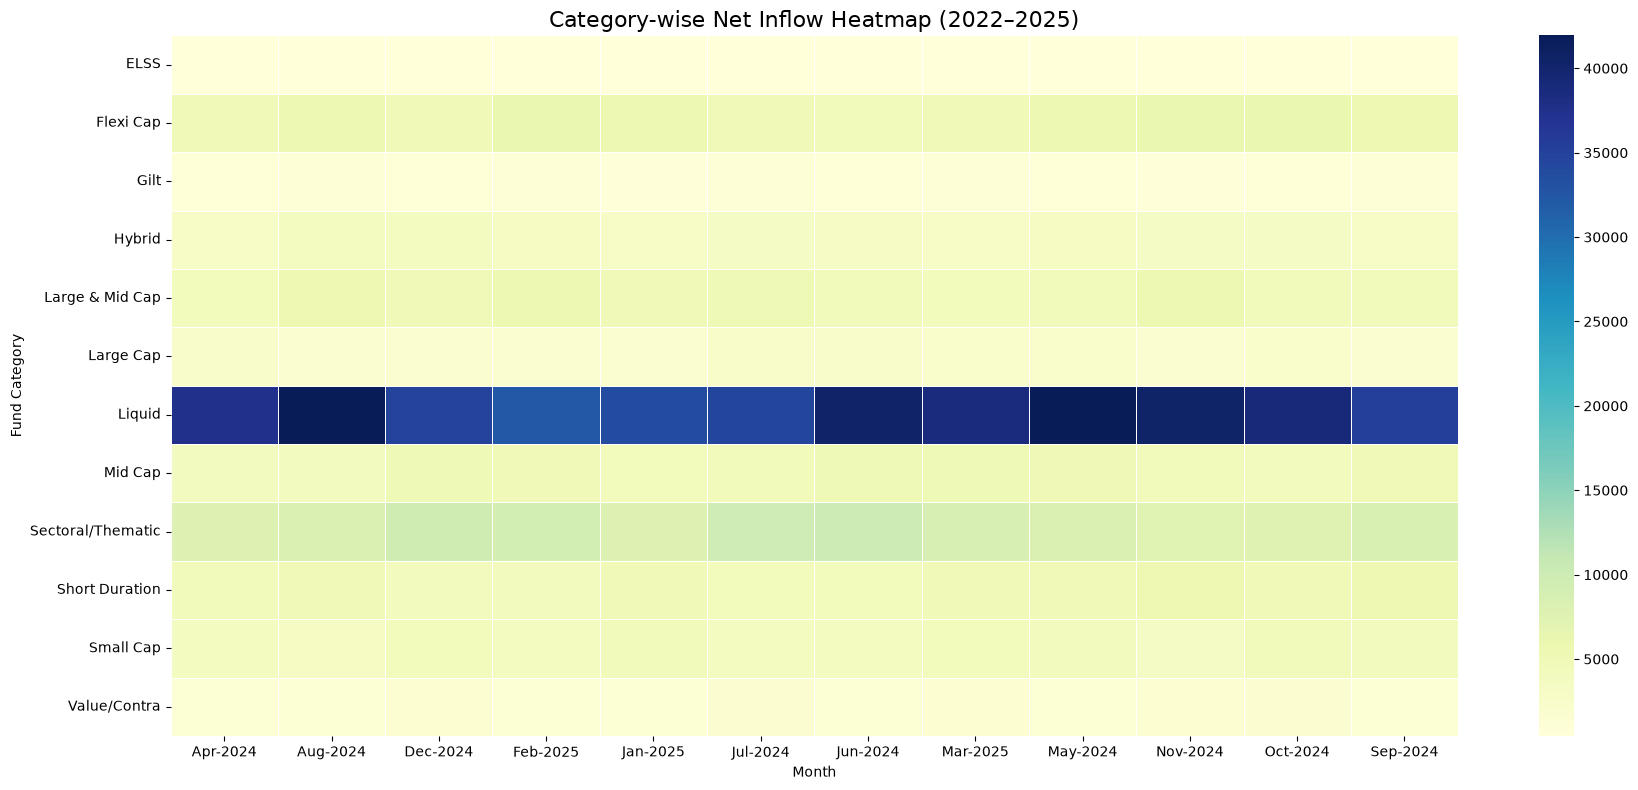

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Net Inflow Heatmap (2022–2025)", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig(
    "../reports/charts/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
investor = pd.read_csv("../data/raw/08_investor_transactions.csv")

In [41]:
investor.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [42]:
age_counts = investor["age_group"].value_counts()

print(age_counts)

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64


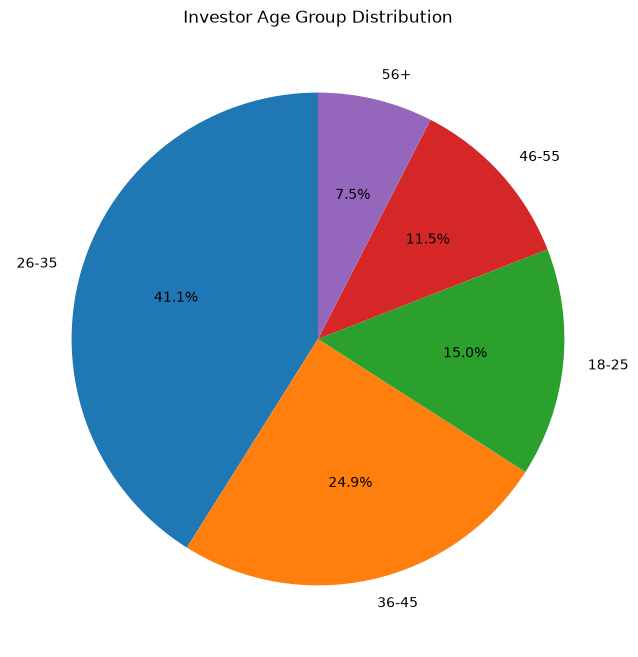

In [43]:
plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../reports/charts/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
sip_data = investor[
    investor["transaction_type"] == "SIP"
]

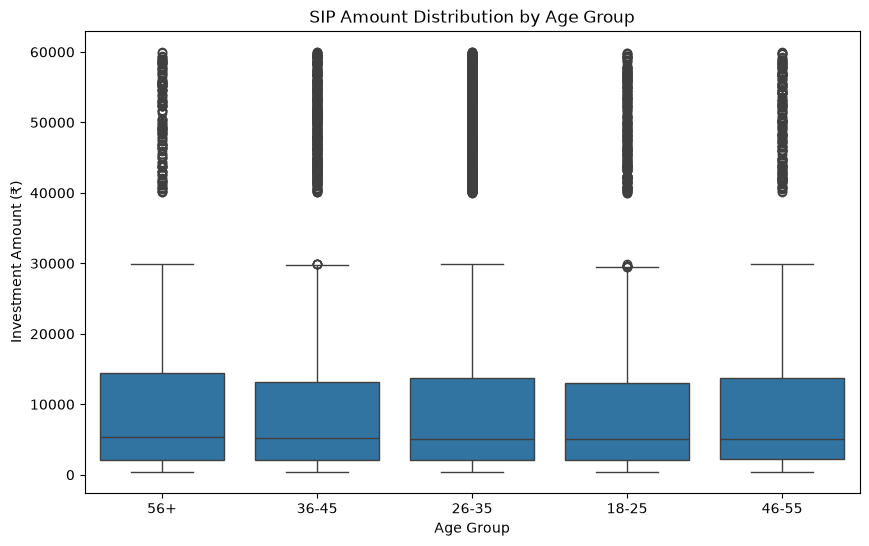

In [45]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_data,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.savefig(
    "../reports/charts/sip_amount_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
gender_counts = investor["gender"].value_counts()

print(gender_counts)

gender
Male      21809
Female    10969
Name: count, dtype: int64


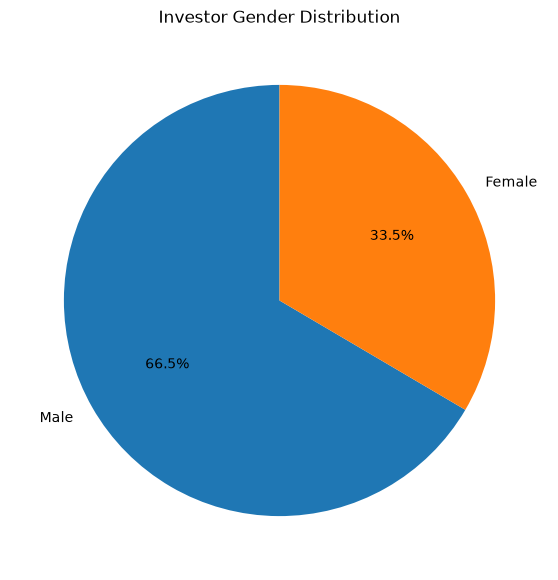

In [47]:
plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Gender Distribution")

plt.savefig(
    "../reports/charts/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
state_sip = investor.groupby("state")["amount_inr"].sum().sort_values(ascending=False)

print(state_sip.head())

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
Name: amount_inr, dtype: int64


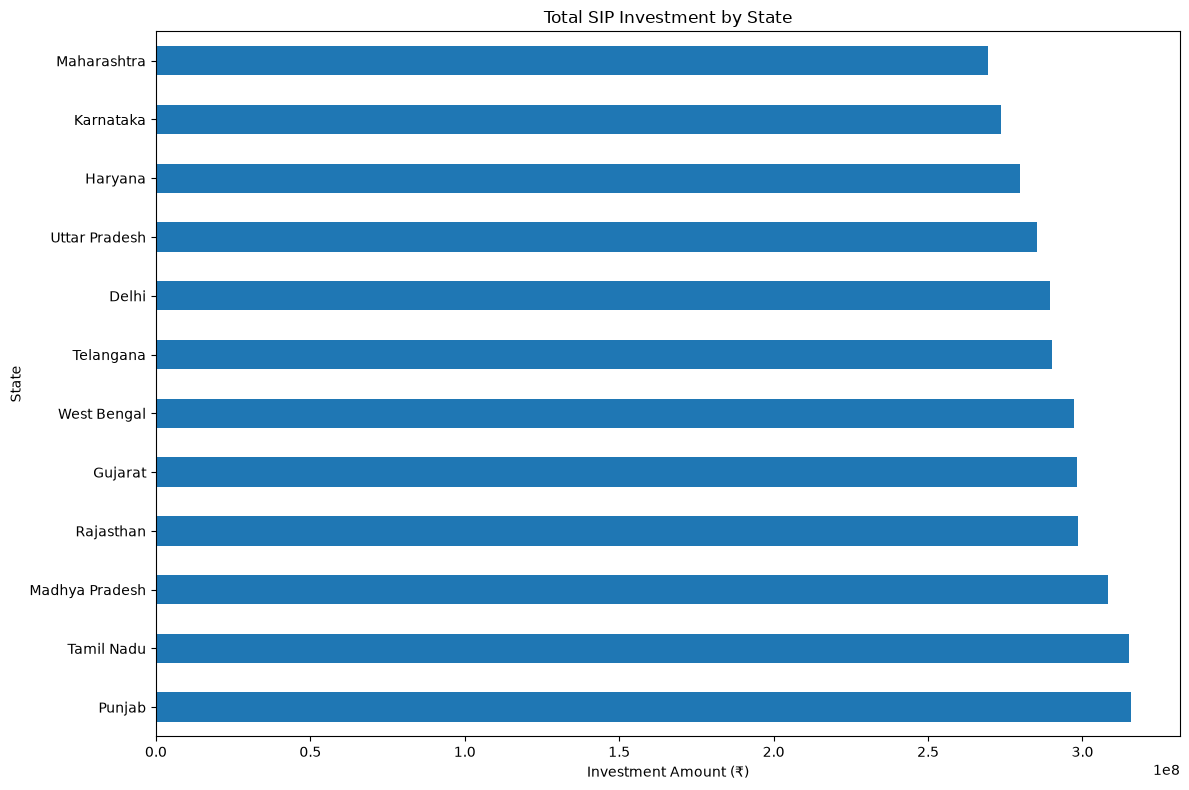

In [50]:
plt.figure(figsize=(12,8))

state_sip.plot(kind="barh")

plt.title("Total SIP Investment by State")
plt.xlabel("Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/charts/state_sip_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
city_tier = investor["city_tier"].value_counts()

print(city_tier)

city_tier
T30    21719
B30    11059
Name: count, dtype: int64


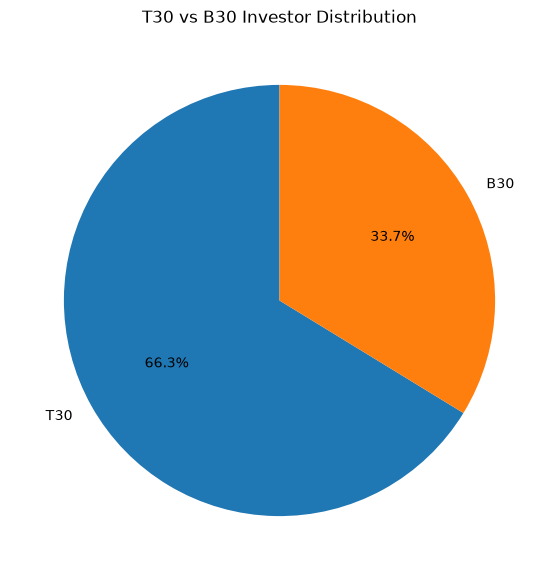

In [52]:
plt.figure(figsize=(7,7))

plt.pie(
    city_tier,
    labels=city_tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig(
    "../reports/charts/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

In [54]:
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

In [55]:
folio["month"] = pd.to_datetime(folio["month"])

In [56]:
print(folio.head(1))
print(folio.tail(1))

       month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0 2022-01-01               13.26                 9.28               1.86   

   hybrid_folios_crore  others_folios_crore  
0                  0.8                 1.33  
        month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
20 2025-12-01               26.12                18.28               3.66   

    hybrid_folios_crore  others_folios_crore  
20                 1.57                 2.61  


In [58]:
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Mutual Fund Industry Folio Growth (2022–2025)"
)

fig.add_annotation(
    x="2022-01-01",
    y=13.26,
    text="Start: 13.26 Cr",
    showarrow=True,
    arrowhead=2
)

fig.add_annotation(
    x="2025-12-01",
    y=26.12,
    text="End: 26.12 Cr",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)"
)

fig.show()

In [ ]:
fig.write_image("../reports/charts/folio_growth.png")

In [60]:
nav.columns

Index(['amfi_code', 'date', 'nav', 'scheme_name'], dtype='str')

In [61]:
nav = nav.sort_values(["scheme_name", "date"])

In [62]:
selected_funds = nav["scheme_name"].unique()[:10]

print(selected_funds)

<StringArray>
['ABSL Frontline Equity Fund - Regular - Growth',
           'ABSL Liquid Fund - Regular - Growth',
        'ABSL Small Cap Fund - Regular - Growth',
          'Axis Bluechip Fund - Direct - Growth',
         'Axis Bluechip Fund - Regular - Growth',
           'Axis Midcap Fund - Regular - Growth',
        'Axis Small Cap Fund - Regular - Growth',
            'DSP Midcap Fund - Regular - Growth',
         'DSP Small Cap Fund - Regular - Growth',
    'DSP Top 100 Equity Fund - Regular - Growth']
Length: 10, dtype: str


In [63]:
nav10 = nav[
    nav["scheme_name"].isin(selected_funds)
]

In [64]:
nav10["daily_return"] = (
    nav10.groupby("scheme_name")["nav"]
    .pct_change()
)

In [65]:
returns = nav10.pivot_table(
    index="date",
    columns="scheme_name",
    values="daily_return"
)

In [66]:
corr = returns.corr()

corr.head()

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,Axis Bluechip Fund - Direct - Growth,Axis Bluechip Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth,Axis Small Cap Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,DSP Top 100 Equity Fund - Regular - Growth
scheme_name,,,,,,,,,,
ABSL Frontline Equity Fund - Regular - Growth,1.000000,-0.027230,0.010202,0.012036,0.056952,-0.040309,-0.029799,-0.000607,-0.004785,0.021622
ABSL Liquid Fund - Regular - Growth,-0.027230,1.000000,-0.007530,-0.038607,-0.029781,0.010877,0.039690,0.027775,-0.010105,0.020234
ABSL Small Cap Fund - Regular - Growth,0.010202,-0.007530,1.000000,0.056726,0.013961,0.017462,-0.029528,0.011435,-0.006471,0.020669
Axis Bluechip Fund - Direct - Growth,0.012036,-0.038607,0.056726,1.000000,-0.003216,0.030734,-0.009111,0.016425,0.017761,0.006239
Axis Bluechip Fund - Regular - Growth,0.056952,-0.029781,0.013961,-0.003216,1.000000,0.015815,0.037383,-0.023655,0.013288,0.018544


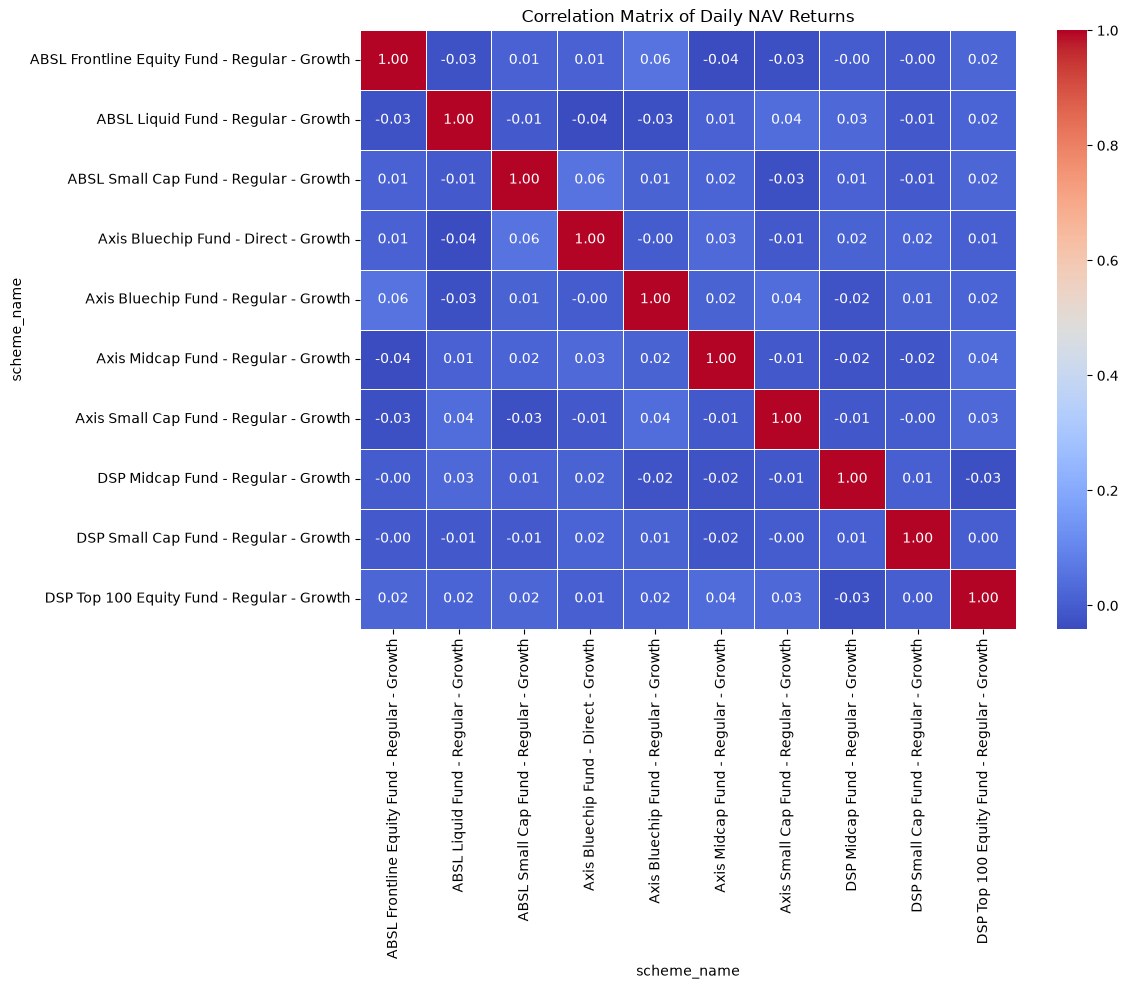

In [67]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.tight_layout()

plt.savefig(
    "../reports/charts/nav_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [68]:
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [69]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [70]:
sector = portfolio.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

print(sector)

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64


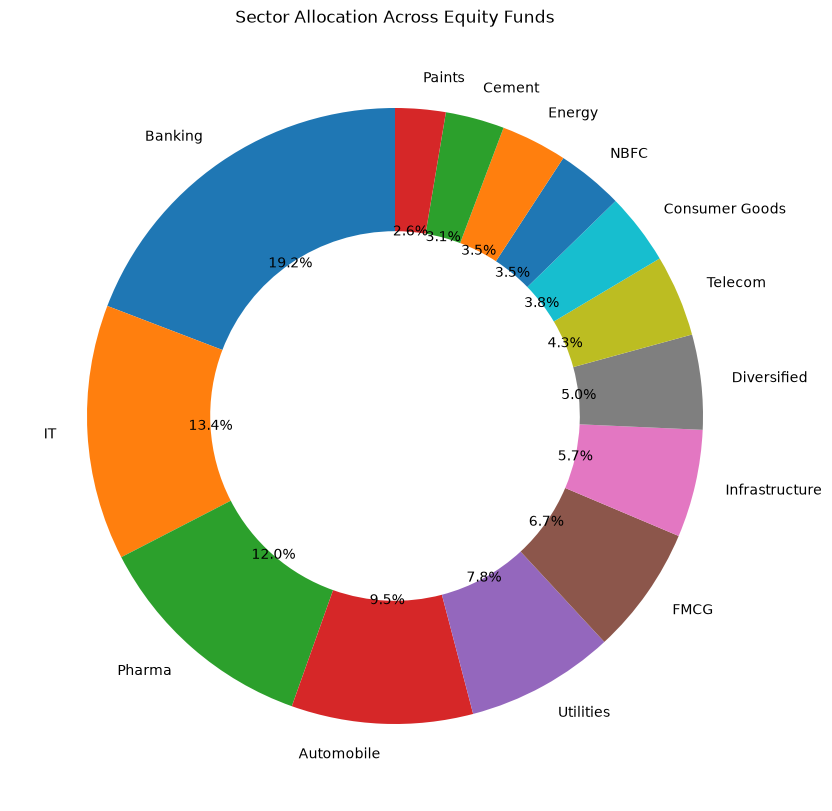

In [71]:
plt.figure(figsize=(10,10))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation Across Equity Funds")

plt.savefig(
    "../reports/charts/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 1
The daily NAV of most mutual fund schemes showed a strong upward trend during 2023, indicating a broad market bull run.

### Insight 2
Several schemes experienced slower NAV growth and periods of correction during 2024, reflecting changing market conditions.

### Insight 3
SBI Mutual Fund recorded the highest Assets Under Management (AUM), reaching approximately ₹12.5 lakh crore in 2025.

### Insight 4
Monthly SIP inflows increased consistently and reached an all-time high of ₹31,002 crore in December 2025.

### Insight 5
Equity-oriented mutual fund categories attracted higher net inflows compared to several other fund categories during the analysis period.

### Insight 6
The majority of investors belonged to the middle-age groups, indicating higher participation from working professionals.

### Insight 7
Large metropolitan (T30) cities contributed a greater share of mutual fund investments than B30 cities.

### Insight 8
The total mutual fund folio count nearly doubled from 13.26 crore in January 2022 to 26.12 crore in December 2025, reflecting strong retail investor growth.

### Insight 9
Daily NAV returns of large-cap equity schemes showed positive correlations, indicating similar movement across comparable funds.

### Insight 10
Financial Services, Information Technology, and Healthcare were among the largest sectors in mutual fund equity portfolios.